# Demo - LISA Horizon Distance
This demo shows how to use ``LEGWORK`` to compute the horizon distance for a collection of sources.

In [1]:
%matplotlib inline

In [2]:
import legwork as lw
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

In [3]:
%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

## Horizon distance of circular binaries
The horizon distance for a source is the maximum distance at which the SNR of a source is still above some detectable threshold. The horizon distance can be computed from the SNR as follows since it is inversely proportional to the distance.

\begin{equation}
D_{\rm hor} = \frac{\rho(D)}{\rho_{\rm detect}} \cdot D,
\label{eq:snr_to_hor_dist}
\end{equation}

Where $\rho(D)$ is the SNR at some distance $D$ and $\rho_{\rm detect}$ is the SNR above which we consider a source detectable.

Let's start doing this by creating a grid of chirp masses and orbital frequencies and creating a Source class from them.

In [4]:
# create a list of masses and frequencies
m_c_grid = np.logspace(-1, np.log10(50), 500) * u.Msun
f_orb_grid = np.logspace(np.log10(4e-5), np.log10(3e-1), 400) * u.Hz

# turn the two lists into grids
MC, FORB = np.meshgrid(m_c_grid, f_orb_grid)

# flatten grids
m_c, f_orb = MC.flatten(), FORB.flatten()

# convert chirp mass to individual masses for source class
q = 1.0
m_1 = m_c / q**(3/5) * (1 + q)**(1/5)
m_2 = m_1 * q

# use a fixed distance and circular binaries
dist = np.repeat(1, len(m_c)) * u.kpc
ecc = np.zeros(len(m_c))

# create the source class
sources = lw.source.Source(m_1=m_1, m_2=m_2, dist=dist, f_orb=f_orb, ecc=ecc, gw_lum_tol=1e-3)

Next, we can use `LEGWORK` to compute their merger times and SNRs for the contours.

In [5]:
# calculate merger times and then SNR
sources.get_merger_time()
sources.get_snr(verbose=True)

Calculating SNR for 200000 sources
	0 sources have already merged
	125169 sources are stationary
		125169 sources are stationary and circular
	74831 sources are evolving
		74831 sources are evolving and circular


array([5.37042162e-04, 5.48305975e-04, 5.59806032e-04, ...,
       1.06803574e+04, 1.07918408e+04, 1.09044902e+04], shape=(200000,))

We flattened the grid to fit into the Source class but now we can reshape the output to match the original grid.

In [6]:
# reshape the output into grids
t_merge_grid = sources.t_merge.reshape(MC.shape)
snr_grid = sources.snr.reshape(MC.shape)

Now we can define a couple of functions for formatting the time, distance and galaxy name contours.

In [7]:
def fmt_time(x):
    if x == 4:
        return r"$t_{\rm merge} = T_{\rm obs}$"
    elif x >= 1e9:
        return "{0:1.0f} Gyr".format(x / 1e9)
    elif x >= 1e6:
        return "{0:1.0f} Myr".format(x / 1e6)
    elif x >= 1e3:
        return "{0:1.0f} kyr".format(x / 1e3)
    elif x >= 1:
        return "{0:1.0f} yr".format(x)
    elif x >= 1/12:
        return "{0:1.0f} month".format(x * 12)
    else:
        return "{0:1.0f} week".format(x * 52)
    
def fmt_dist(x):
    if x >= 1e9:
        return "{0:1.0f} Gpc".format(x / 1e9)
    elif x >= 1e6:
        return "{0:1.0f} Mpc".format(x / 1e6)
    elif x >= 1e3:
        return "{0:1.0f} kpc".format(x / 1e3)
    else:
        return "{0:1.0f} pc".format(x)
    
def fmt_name(x):
    if x == np.log10(8):
        return "MW Centre"
    elif x == np.log10(50):
        return "SMC/LMC"
    elif x == np.log10(800):
        return "Andromeda"
    elif x == np.log10(40000):
        return "GW170817"

Finally, we put it all together to create a contour plot with all of the information.

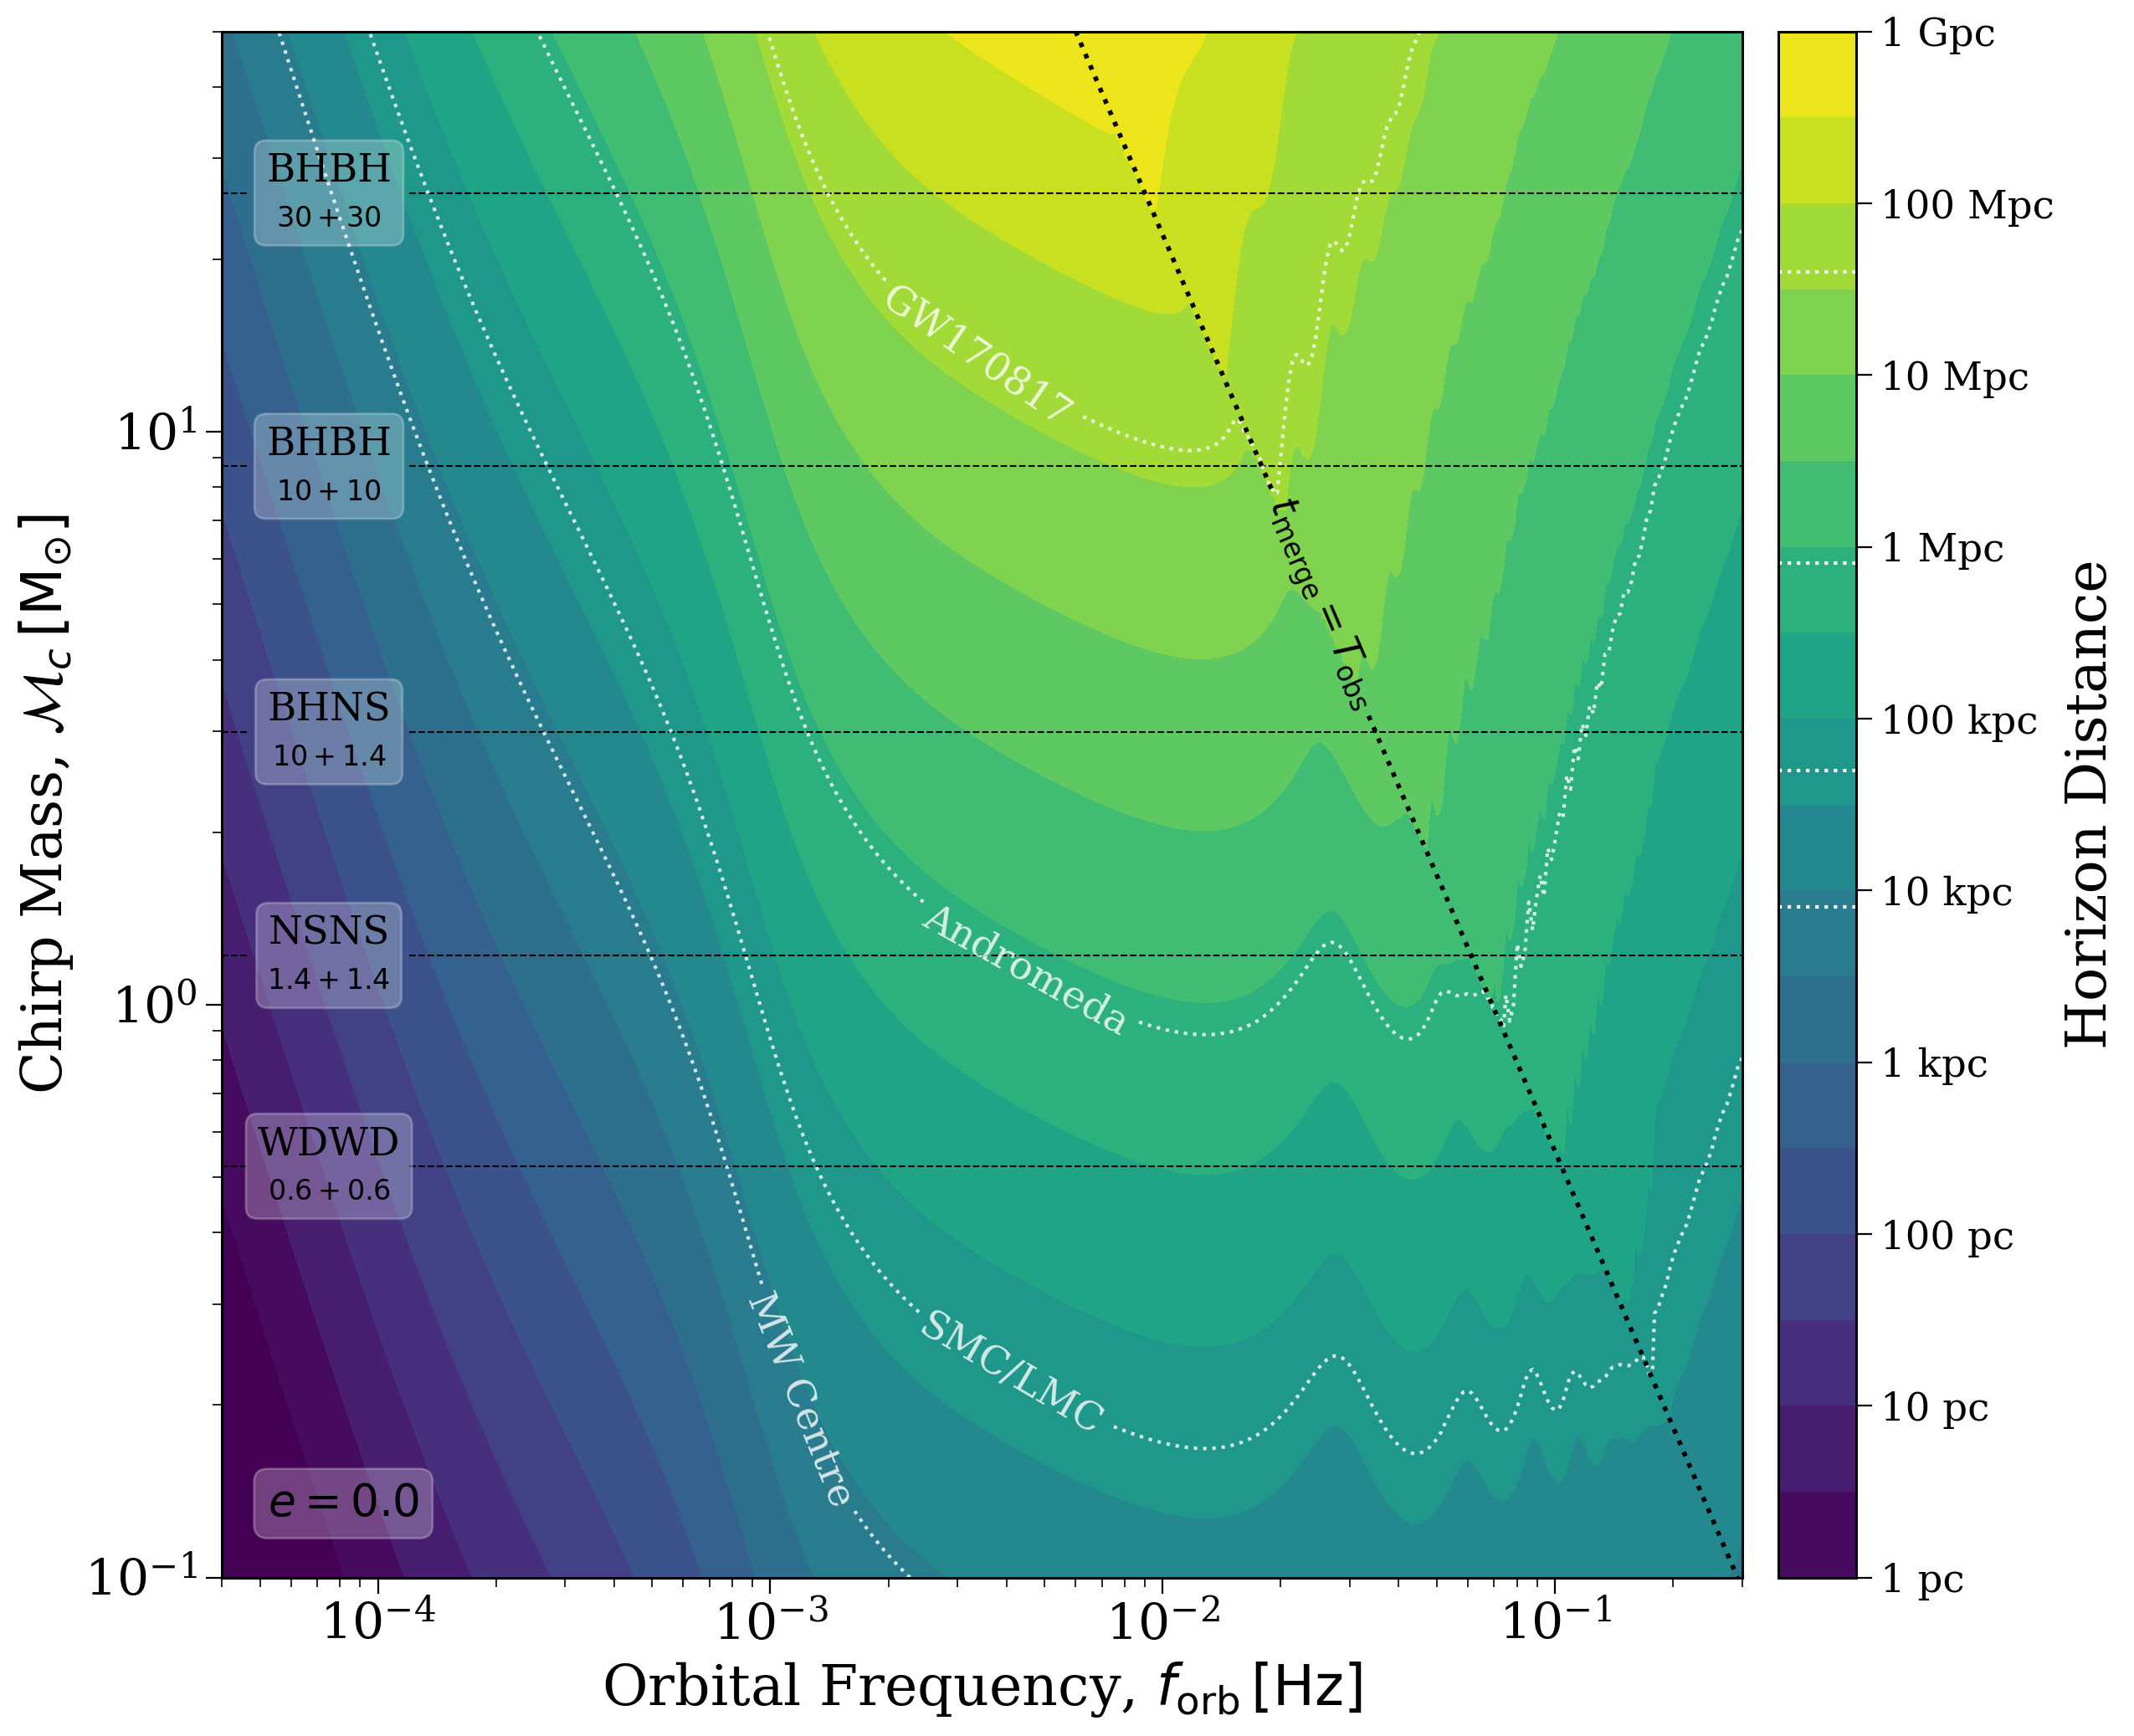

In [8]:
# create a square figure plus some space for a colourbar
size = 12
cbar_space = 2
fig, ax = plt.subplots(figsize=(size + cbar_space, size))

# set up scales early so contour labels show up nicely
ax.set_xscale("log")
ax.set_yscale("log")

# set axes labels and lims
ax.set_xlabel(r"Orbital Frequency, $f_{\rm orb} \, [\rm Hz]$")
ax.set_ylabel(r"Chirp Mass, $\mathcal{M}_c \, [\rm M_{\odot}]$")
ax.set_xlim(4e-5, 3e-1)

# calculate the horizon distance
snr_threshold = 7
horizon_distance = (snr_grid / snr_threshold * 1 * u.kpc).to(u.kpc)

# set up the contour levels
distance_levels = np.arange(-3, 6 + 0.5, 0.5)
distance_tick_levels = distance_levels[::2]

# plot the contours for horizon distance
distance_cont = ax.contourf(FORB, MC, np.log10(horizon_distance.value), levels=distance_levels)

# hide edges that show up in rendered PDFs
distance_cont.set_edgecolors("face")

# create a colour with custom formatted labels
cbar = fig.colorbar(distance_cont, ax=ax, pad=0.02, ticks=distance_tick_levels, fraction=cbar_space / (size + cbar_space))
cbar.ax.set_yticklabels([fmt_dist(np.power(10, distance_tick_levels + 3)[i]) for i in range(len(distance_tick_levels))])
cbar.set_label(r"Horizon Distance", fontsize=fs)
cbar.ax.tick_params(axis="both", which="major", labelsize=0.7 * fs)

# annotate the colourbar with some named distances
named_distances = np.log10([8, 50, 800, 40000])
for name in named_distances:
    cbar.ax.axhline(name, color="white", linestyle="dotted")
    
# plot the same names as contours
named_cont = ax.contour(FORB, MC, np.log10(horizon_distance.value), levels=named_distances,
                        colors="white", alpha=0.8, linestyles="dotted")
ax.clabel(named_cont, named_cont.levels, fmt=fmt_name, use_clabeltext=True, fontsize=0.7*fs,
          manual=[(1.1e-3, 2e-1), (4e-3, 2.2e-1), (4e-3,1e0), (3e-3, 1.2e1)])

# add a line for when the merger time becomes less than the inspiral time
time_cont = ax.contour(FORB, MC, t_merge_grid.to(u.yr).value, levels=[4],
                       colors="black", linewidths=2, linestyles="dotted") #[1/52, 1/12, 4, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]
ax.clabel(time_cont, time_cont.levels, fmt=fmt_time, fontsize=0.7*fs, use_clabeltext=True, manual=[(2.5e-2, 5e0)])

# plot a series of lines and annotations for average DCO masses
for m_1, m_2, dco in [(0.6, 0.6, "WDWD"), (1.4, 1.4, "NSNS"),
                      (10, 1.4, "BHNS"), (10, 10, "BHBH"), (30, 30, "BHBH")]:
    # find chirp mass
    m_c_val = lw.utils.chirp_mass(m_1, m_2)
    
    # plot lines before and after bbox
    ax.plot([4e-5, 4.7e-5], [m_c_val, m_c_val],
            color="black", lw=0.75, zorder=1, linestyle="--")
    ax.plot([1.2e-4, 1e0], [m_c_val, m_c_val],
            color="black", lw=0.75, zorder=1, linestyle="--")
    
    # plot name and bbox, then masses below in smaller font
    ax.annotate(dco + "\n", xy=(7.5e-5, m_c_val), ha="center", va="center", fontsize=0.7*fs,
               bbox=dict(boxstyle="round", fc="white", ec="white", alpha=0.25))
    ax.annotate(r"${{{}}} + {{{}}}$".format(m_1, m_2),
               xy=(7.5e-5, m_c_val * 0.95), ha="center", va="top", fontsize=0.5*fs)
    
# ensure that everyone knows this only applies for circular sources
ax.annotate(r"$e = 0.0$", xy=(0.03, 0.04), xycoords="axes fraction", fontsize=0.8*fs,
            bbox=dict(boxstyle="round", fc="white", ec="white", alpha=0.25))

ax.set_facecolor(plt.get_cmap("viridis")(0.0))

plt.show()